# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

**Based on the paper:** The dataset represents 17 marketing campaigns conducted by telephone by a Portuguese bank between May 2008 and November 2010. Each row corresponds to one contact with a client during one of these campaigns. The objective was to encourage the client to subscribe to a term deposit, similar to opening a savings account.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Exploratory Data Analysis

The target is imbalanced, so the first step is to inspect the outcome distribution and compare customer age and job categories with subscription behavior. These visualizations help identify patterns before modeling.

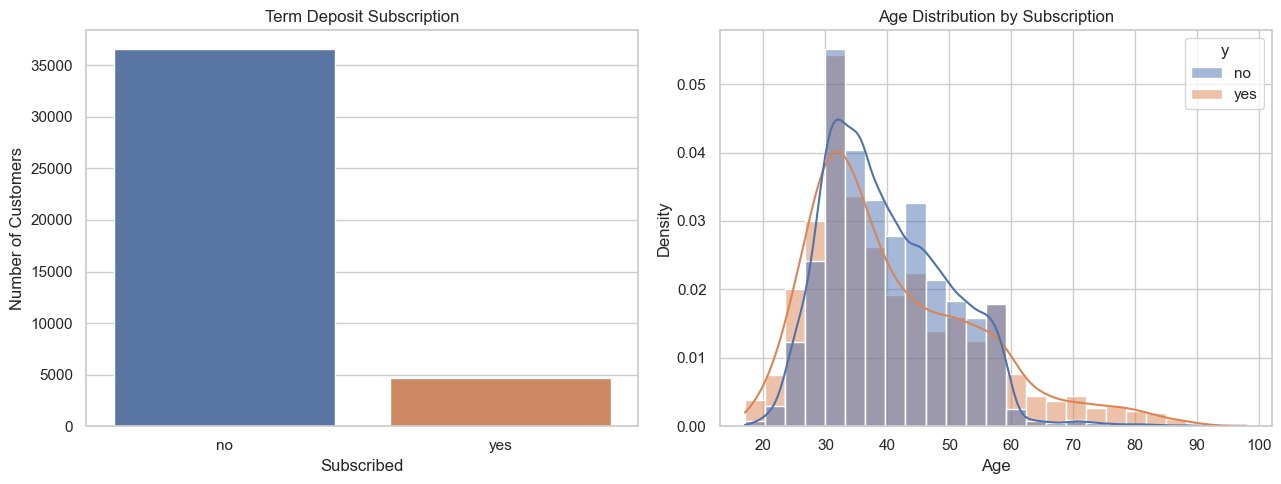

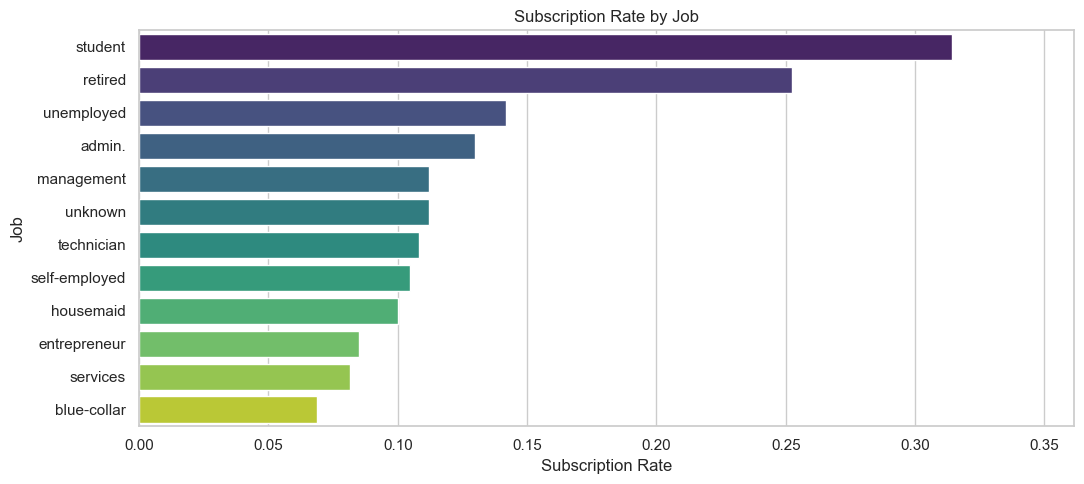

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=df, x='y', hue='y', legend=False, ax=axes[0])
axes[0].set_title('Term Deposit Subscription')
axes[0].set_xlabel('Subscribed')
axes[0].set_ylabel('Number of Customers')

sns.histplot(data=df, x='age', hue='y', bins=25, kde=True, stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Age Distribution by Subscription')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

job_subscription_rate = (
    df.assign(subscribed=(df['y'] == 'yes').astype(int))
      .groupby('job', as_index=False)['subscribed']
      .mean()
      .sort_values('subscribed', ascending=False)
)

plt.figure(figsize=(11, 5))
sns.barplot(data=job_subscription_rate, x='subscribed', y='job', hue='job', legend=False, palette='viridis')
plt.title('Subscription Rate by Job')
plt.xlabel('Subscription Rate')
plt.ylabel('Job')
plt.xlim(0, job_subscription_rate['subscribed'].max() * 1.15)
plt.tight_layout()
plt.show()

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [4]:
print(df.dtypes)
print(df.isnull().sum())


age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [9]:
for col in df.select_dtypes(include=['object', 'str']).columns:
    n_unkown = (df[col] == 'unknown').sum()
    if n_unkown > 0:
        print(f"{col}: {n_unkown} 'unknown' values ({n_unkown / len(df):.2%})")

print("----------------------------------------------------------------")

print("pdays == 999 means client was not previously contacted:", (df['pdays'] == 999).sum())

print("----------------------------------------------------------------")

print(df['y'].value_counts(normalize=True))

print("end=----------------------------------------------------------------")

job: 330 'unknown' values (0.80%)
marital: 80 'unknown' values (0.19%)
education: 1731 'unknown' values (4.20%)
default: 8597 'unknown' values (20.87%)
housing: 990 'unknown' values (2.40%)
loan: 990 'unknown' values (2.40%)
----------------------------------------------------------------
pdays == 999 means client was not previously contacted: 39673
----------------------------------------------------------------
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64
end=----------------------------------------------------------------


There are no true NaN values, but several categorical columns contain `unknown`, which should be treated explicitly. The `pdays` value `999` means that a client was not previously contacted and should not be interpreted as an ordinary numeric value. All categorical columns must be encoded before modeling, and `duration` should be excluded because it is not known before a call.

**Objective:** Build a classification model that predicts, before a call, which clients are more likely to subscribe to a term deposit. This could help the bank reduce campaign time and cost by prioritizing higher-probability clients.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [4]:
#with the objective and problem 5, we nned to chhose X which is our clinet information and y which is yes or no as the target varible (we need to convert yes and no to 1 and 0).

bank_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
X = df[bank_features]
y = df['y'].map({'yes': 1, 'no': 0})  

y.head()

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64

In [5]:
categorial_features = ['job', 'marital', 'education', 'default', 'housing', 'loan']
X_encoded = pd.get_dummies(X, columns=categorial_features, drop_first=True)

In [17]:
print(X_encoded.shape)
X_encoded.head()


(41188, 28)


,age,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes
0,56,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,57,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
2,37,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,40,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,56,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.25, random_state=42, stratify=y)

In [20]:
print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

Train Shape: (30891, 28), Test Shape: (10297, 28)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [9]:
from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.89,0.11]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](28,)","['age','job_blue-collar','job_entrepreneur',...,'housing_yes', 'loan_unknown','loan_yes']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,28
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [22]:
baseline_train_acc = baseline_model.score(X_train, y_train)
baseline_test_acc = baseline_model.score(X_test, y_test)
print(f"Baseline Train Accuracy: {baseline_train_acc:.4f}")
print(f"Baseline Test Accuracy: {baseline_test_acc:.4f}")

Baseline Train Accuracy: 0.8873
Baseline Test Accuracy: 0.8873


**Key takeaway:** Approximately 88% of clients did not subscribe, so the classes are imbalanced. Accuracy alone can be misleading; precision, recall, F1 score, ROC AUC, and average precision provide a more complete evaluation.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [10]:
from sklearn.linear_model import LogisticRegression

lgr = LogisticRegression(max_iter=1000, random_state=42)
lgr.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### Problem 9: Score the Model

What is the accuracy of your model?

In [24]:
lgr_train_acc = lgr.score(X_train, y_train)
lgr_test_acc = lgr.score(X_test, y_test)
print(f"Logistic Regression Train Accuracy: {lgr_train_acc:.4f}")
print(f"Logistic Regression Test Accuracy: {lgr_test_acc:.4f}")

Logistic Regression Train Accuracy: 0.8873
Logistic Regression Test Accuracy: 0.8873


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [11]:
import time
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

model = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

In [12]:
results = []
for name, model in model.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start_time
    results.append({
        'Model': name,
        "Train Time": fit_time,
        'Train Accuracy': model.score(X_train, y_train),
        'Test Accuracy': model.score(X_test, y_test),
    })

In [26]:
results_df = pd.DataFrame(results)
results_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.207371,0.887346,0.887346
1,KNN,0.004736,0.890810,0.874429
2,Decision Tree,0.046512,0.917775,0.865592
3,SVM,4.790222,0.887346,0.887346


**Where we are now:** With only bank-client features, the models perform close to the majority-class baseline. KNN and Decision Tree have the shortest training times, but the expanded feature set is needed to improve discrimination between subscribers and non-subscribers.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [13]:
feature_cols = []
for c in df.columns:
    if c not in ['y', 'duration']:
        feature_cols.append(c)
X_full = df[feature_cols]
y_full = df['y'].map({'yes': 1, 'no': 0})


## now we need to do the same as what we did above: encode the the catogorial columns 

categorial_cols = X_full.select_dtypes(include=['object', 'str']).columns.to_list()
X_full_encoded = pd.get_dummies(X_full, columns=categorial_cols, drop_first=True)
X_full_encoded



,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
1,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,False,...,False,True,False,False,False,False,False,False,True,False
41184,46,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,True,...,False,True,False,False,False,False,False,False,True,False
41185,56,2,999,0,-1.1,94.767,-50.8,1.028,4963.6,False,...,False,True,False,False,False,False,False,False,True,False
41186,44,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,False,...,False,True,False,False,False,False,False,False,True,False


In [14]:
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full_encoded, y_full, test_size=0.2, random_state=42)

In [17]:
## now I want to use grid search to find the best hyperparameters for the models we have used above.

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

param_grid = {
    'Logistic Regression': (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=1000, random_state=42)),
        ]),
        {'model__C': [0.01, 0.1, 1, 10]},
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [5, 15, 25, 35]},
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [3, 5, 10, None]},
    ),
    'SVM': (
        SVC(random_state=42, probability=True),
        {'C': [1, 10], 'kernel': ['rbf']},
    ),
}

In [18]:
tuned_results = []
best_models = {}

for name, (estimator, grid) in param_grid.items():
    start = time.time()
    gs = GridSearchCV(estimator, grid, cv=3, scoring='roc_auc', n_jobs=-1)
    gs.fit(X_train_full, y_train_full)
    fit_time = time.time() - start
    best_models[name] = gs.best_estimator_

    tuned_results.append({
        'Model': name,
        'Best Params': gs.best_params_,
        'Train Time': fit_time,
        'Train Accuracy': gs.best_estimator_.score(X_train_full, y_train_full),
        'Test Accuracy': gs.best_estimator_.score(X_test_full, y_test_full),
        'CV ROC AUC': gs.best_score_,
    })

c:\Users\sshad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [19]:
tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df

,Model,Best Params,Train Time,Train Accuracy,Test Accuracy,CV ROC AUC
0,Logistic Regression,{'model__C': 0.1},0.343593,0.901153,0.897184,0.793727
1,KNN,{'n_neighbors': 25},1.081477,0.902762,0.894149,0.777638
2,Decision Tree,{'max_depth': 5},0.243322,0.904492,0.896213,0.782648
3,SVM,"{'C': 10, 'kernel': 'rbf'}",71.744119,0.898209,0.894756,0.649529


**Where we are now:** The grid search identified the best hyperparameters for each model. We now compare their ROC AUC scores on the held-out test set and visualize the ROC curves.

In [20]:
from sklearn.metrics import roc_auc_score, roc_curve

test_auc_scores = {}
for name, model in best_models.items():
    y_score = model.predict_proba(X_test_full)[:, 1]
    test_auc_scores[name] = roc_auc_score(y_test_full, y_score)

test_auc_scores


{'Logistic Regression': 0.7805565949382753,
 'KNN': 0.7646023427483101,
 'Decision Tree': 0.7674816810321156,
 'SVM': 0.7441472664153109}

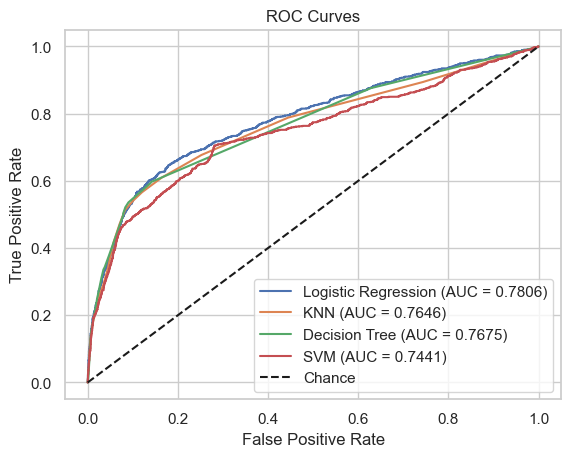

In [24]:
import matplotlib.pyplot as plt

for name, model in best_models.items():
    y_score = model.predict_proba(X_test_full)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_full, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {test_auc_scores[name]:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

### Evaluation Beyond Accuracy

Because only 11.27% of customers subscribed, accuracy can hide poor performance on the positive class. The tuned Logistic Regression model is evaluated with precision, recall, F1 score, ROC AUC, average precision, and a confusion matrix.

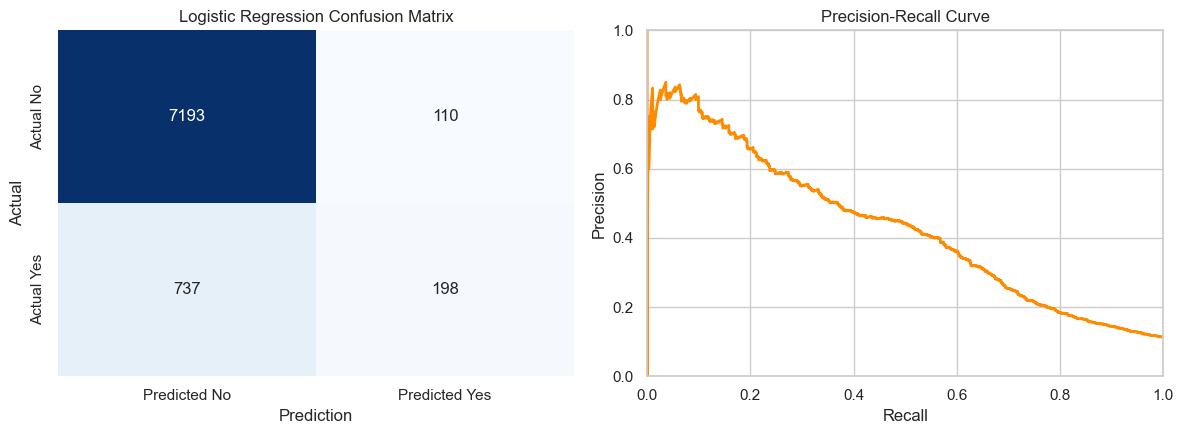

In [22]:
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

logistic_model = best_models['Logistic Regression']
y_pred = logistic_model.predict(X_test_full)
y_probability = logistic_model.predict_proba(X_test_full)[:, 1]

metric_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'Average Precision'],
    'Score': [
        logistic_model.score(X_test_full, y_test_full),
        precision_score(y_test_full, y_pred),
        recall_score(y_test_full, y_pred),
        f1_score(y_test_full, y_pred),
        roc_auc_score(y_test_full, y_probability),
        average_precision_score(y_test_full, y_probability),
    ],
})
metric_summary.round(3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
confusion = confusion_matrix(y_test_full, y_pred)
sns.heatmap(
    confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes'],
    ax=axes[0],
)
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Prediction')
axes[0].set_ylabel('Actual')

precision_values, recall_values, _ = precision_recall_curve(y_test_full, y_probability)
axes[1].plot(recall_values, precision_values, color='darkorange', linewidth=2)
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

**in the paper, they also mentioned which features the tuned decision tree relied on most. Then build a summary and compasrion**

<Axes: >

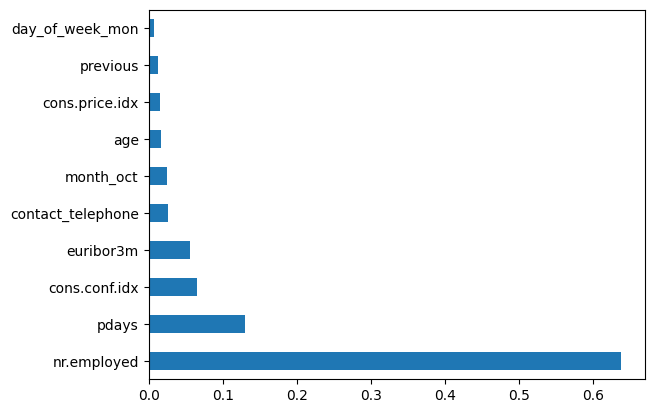

In [50]:
importances = pd.Series(
    best_models['Decision Tree'].feature_importances_, index=X_full_encoded.columns
)
importances.sort_values(ascending=False).head(10).plot(kind='barh')

In [27]:
compare_df = results_df[['Model', 'Test Accuracy']].merge(
    tuned_results_df[['Model', 'Test Accuracy', 'CV ROC AUC']], 
    on='Model', 
    suffixes=('_Baseline', '_Full Features + Tuning')
)
compare_df

,Model,Test Accuracy_Baseline,Test Accuracy_Full Features + Tuning,CV ROC AUC
0,Logistic Regression,0.887346,0.897184,0.793727
1,KNN,0.874429,0.894149,0.777638
2,Decision Tree,0.865592,0.896213,0.782648
3,SVM,0.887346,0.894756,0.649529


**Observations:** Moving from the bank-clinet-only fetaure set to fuller set, combined with hyperparameter tunning and scoring on ROC AUC, should noticeably imporve discrimination between subscribers and non-subscribers versus the simple baseline model --> this is very obvious that more related data can help to imporve the model and it is shown here as well

## Findings and Recommendations

### Findings

1. The target is imbalanced: 88.73% of customers did not subscribe and 11.27% did subscribe.
2. The majority-class baseline achieved 88.73% accuracy, so accuracy alone is not an adequate success criterion.
3. Models using only basic bank-client information performed near the baseline.
4. Adding campaign, contact, previous-outcome, and economic-context features improved test accuracy to approximately 89.7%.
5. Tuned Logistic Regression was the strongest overall model in this experiment, with test accuracy of 0.8972 and test ROC AUC of 0.7806.
6. The age and job visualizations suggest that subscription rates vary across customer groups, but these patterns should be treated as predictive associations rather than causal conclusions.

### Recommendations and Next Steps

- Use the tuned Logistic Regression model to rank customers by predicted subscription probability rather than using a simple yes/no cutoff.
- Select an operating threshold using campaign capacity and the relative cost of missed subscribers versus unnecessary calls.
- Report precision, recall, F1 score, ROC AUC, and average precision alongside accuracy for future model comparisons.
- Validate the model with a consistent stratified holdout or time-based split before comparing models or deploying it.
- Investigate how `unknown` categories and the special `pdays=999` value should be handled with the bank's domain experts.
- Monitor performance over time because campaign response rates and economic conditions may change.